<a href="https://colab.research.google.com/github/Wequiston/Adapter/blob/master/Analise_Dados_SoLetras_BI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analise_Dados_SoLetras_BI
**Projeto:** Inteligência de Marketing e Gestão de Dados (Estudo de Caso)
**Autor:** Wequiston Márcio de Souza Alves
**Objetivo:** Converter dados de engajamento social em métricas estratégicas de Business Intelligence.

## 1. IMPORTAÇÃO DE BIBLIOTECAS E CONFIGURAÇÃO DO AMBIENTE

Nesta etapa inicial, realizamos o carregamento das bibliotecas essenciais para o pipeline de dados. A escolha das ferramentas reflete as necessidades de manipulação, análise estatística e visualização de Business Intelligence:

* **Pandas:** Para a estruturação e manipulação da base de dados em DataFrames.
* **NumPy:** Para operações matemáticas e geração de dados aleatórios consistentes.
* **Seaborn & Matplotlib:** Para a criação de gráficos de alta qualidade e visualização de indicadores (KPIs).

Também configuramos o estilo visual `whitegrid` para garantir que os gráficos apresentem uma estética profissional, facilitando a interpretação dos resultados por parte da gestão da Livraria Só Letras.

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Configuração visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

print("Bibliotecas importadas e ambiente configurado com sucesso!")

Bibliotecas importadas e ambiente configurado com sucesso!


## 2. CRIAÇÃO DA BASE DE DADOS (SIMULAÇÃO DAS FICHAS)

Nesta etapa, procedemos à geração de um *dataset* sintético para representar o volume de informações coletadas pela Livraria Só Letras durante as campanhas nas escolas e indústrias parceiras. A simulação de dados é uma prática fundamental para validar a arquitetura de Business Intelligence antes da implementação em larga escala.

Foram gerados **100 registros**, simulando as fichas de inscrição preenchidas pelos pais, contendo as seguintes variáveis estratégicas:

* **ID_Participante:** Identificador único para garantir a integridade dos dados.
* **Escola:** Segmentação regional (Escola A e Escola B).
* **Tema_Interesse:** Categorização baseada nos temas das "Lives para uma criança" (Saúde, Meio Ambiente, Empatia e Educação).
* **Engajamento_Live:** Métrica de 1 a 10 que representa a interação com os conteúdos digitais.
* **Visita_Industria:** Variável binária (0 ou 1) indicando a participação no evento prático nas fábricas.
* **Valor_Compra:** Variável de saída (Target), modelada com base no comportamento de engajamento e participação nos eventos.

In [5]:
# Semente para garantir que os resultados sejam sempre os mesmos ao rodar o código
np.random.seed(42)

n_registros = 100

data = {
    'ID_Participante': range(1, n_registros + 1),
    'Escola': np.random.choice(['Escola A', 'Escola B'], n_registros),
    'Tema_Interesse': np.random.choice(['Saúde', 'Meio Ambiente', 'Empatia', 'Educação'], n_registros),
    'Engajamento_Live': np.random.randint(1, 11, n_registros),
    'Visita_Industria': np.random.choice([0, 1], n_registros),
    'Valor_Compra': []
}

# Criando lógica de negócio: Participação na indústria e alto engajamento aumentam o Valor de Compra
for i in range(n_registros):
    base_gasto = data['Engajamento_Live'][i] * 15
    bonus_industria = 50 if data['Visita_Industria'][i] == 1 else 0
    ruido = np.random.normal(0, 10) # Simula variações naturais de consumo
    gasto = base_gasto + bonus_industria + ruido
    data['Valor_Compra'].append(round(max(0, gasto), 2))

df = pd.DataFrame(data)

print("Processo de criação do Dataset finalizado com sucesso.")
print("\nPrimeiros 5 registros da base simulada:")
display(df.head())

Processo de criação do Dataset finalizado com sucesso.

Primeiros 5 registros da base simulada:


,ID_Participante,Escola,Tema_Interesse,Engajamento_Live,Visita_Industria,Valor_Compra
0,1,Escola A,Empatia,7,1,168.64
1,2,Escola B,Meio Ambiente,1,0,26.72
2,3,Escola A,Meio Ambiente,4,0,56.27
3,4,Escola A,Educação,4,1,115.04
4,5,Escola A,Meio Ambiente,5,1,152.84


## 3. PROCESSAMENTO ESTATÍSTICO E ANÁLISE DE CORRELAÇÃO

Nesta fase, aplicamos técnicas de estatística inferencial para validar a eficácia da estratégia de marketing digital da Livraria Só Letras. O foco está em identificar como as variáveis de comportamento se associam ao faturamento.

Utilizamos a **Matriz de Correlação de Pearson** para medir a força da associação entre as variáveis. O coeficiente de correlação varia de -1 a 1, onde valores próximos a 1 indicam uma relação direta forte.

* **Objetivo:** Comprovar se o nível de interação nas "Lives" e a participação nos eventos industriais resultam em um aumento real no ticket médio da Feira do Livro.
* **Visualização de Regressão:** Apresentamos um gráfico de dispersão com linha de tendência para ilustrar a previsibilidade do consumo com base no engajamento.

Matriz de Correlação de Pearson:


,Engajamento_Live,Visita_Industria,Valor_Compra
Engajamento_Live,1.000000,-0.010159,0.843001
Visita_Industria,-0.010159,1.000000,0.495928
Valor_Compra,0.843001,0.495928,1.000000


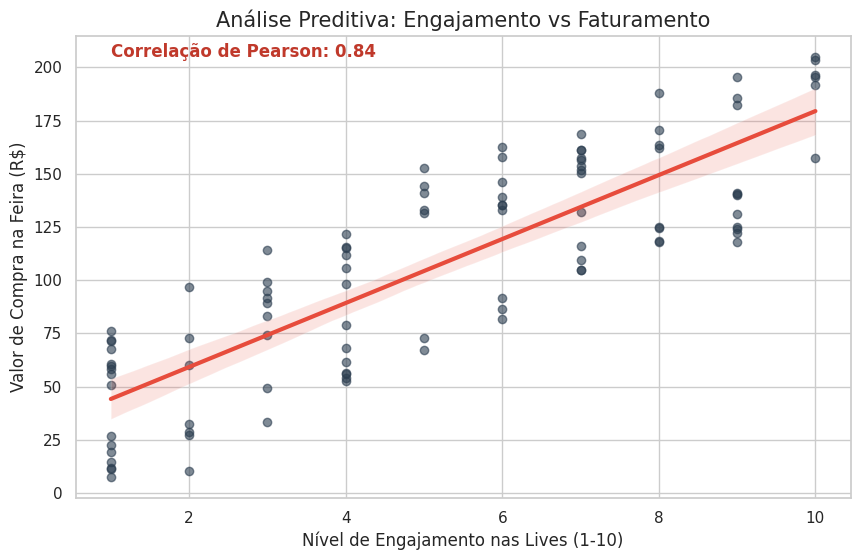

In [6]:
# 1. Cálculo da Matriz de Correlação
# Selecionamos apenas as colunas numéricas para a correlação
df_corr = df[['Engajamento_Live', 'Visita_Industria', 'Valor_Compra']].corr()

print("Matriz de Correlação de Pearson:")
display(df_corr)

# 2. Visualização Técnica: Gráfico de Regressão Linear
plt.figure(figsize=(10, 6))
sns.regplot(x='Engajamento_Live', y='Valor_Compra', data=df,
            scatter_kws={'alpha':0.6, 'color':'#2c3e50'},
            line_kws={'color':'#e74c3c', 'lw':3})

plt.title('Análise Preditiva: Engajamento vs Faturamento', fontsize=15)
plt.xlabel('Nível de Engajamento nas Lives (1-10)', fontsize=12)
plt.ylabel('Valor de Compra na Feira (R$)', fontsize=12)

# Adicionando uma anotação sobre a correlação encontrada
corr_val = df_corr.loc['Engajamento_Live', 'Valor_Compra']
plt.annotate(f'Correlação de Pearson: {corr_val:.2f}', xy=(1, df['Valor_Compra'].max()),
             fontsize=12, color='#c0392b', fontweight='bold')

plt.show()

## 4. GOVERNANÇA DE DADOS E SEGMENTAÇÃO ESTRATÉGICA (BI)

Nesta etapa final, utilizamos os dados processados para criar uma estrutura de **Governança e Inteligência**. O objetivo é transformar a base de dados em segmentos acionáveis, permitindo que a gestão da Livraria Só Letras tome decisões personalizadas para cada perfil de cliente.

Implementamos uma lógica de classificação baseada no comportamento de compra e engajamento:

1.  **Futuro Talento (Foco Industrial):** Clientes com alto ticket médio e que participaram ativamente das visitas às fábricas.
2.  **Entusiasta de Educação:** Clientes com alto nível de engajamento nas transmissões digitais (Lives).
3.  **Leitor Casual:** Clientes que possuem um vínculo inicial, mas que necessitam de estratégias de retenção para aumentar seu ciclo de vida (LTV).

Essa segmentação é o que permite à assessoria de marketing digital criar réguas de comunicação específicas, otimizando o investimento em publicidade e fortalecendo o ecossistema educacional da região.

Resumo da Segmentação de Clientes:


/tmp/ipykernel_7038/322810454.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segmentos_count.index, y=segmentos_count.values, palette='viridis')


,Total de Clientes
Segmento_Estrategico,
Leitor Casual,71
Futuro Talento (Foco Industrial),16
Entusiasta de Educação,13


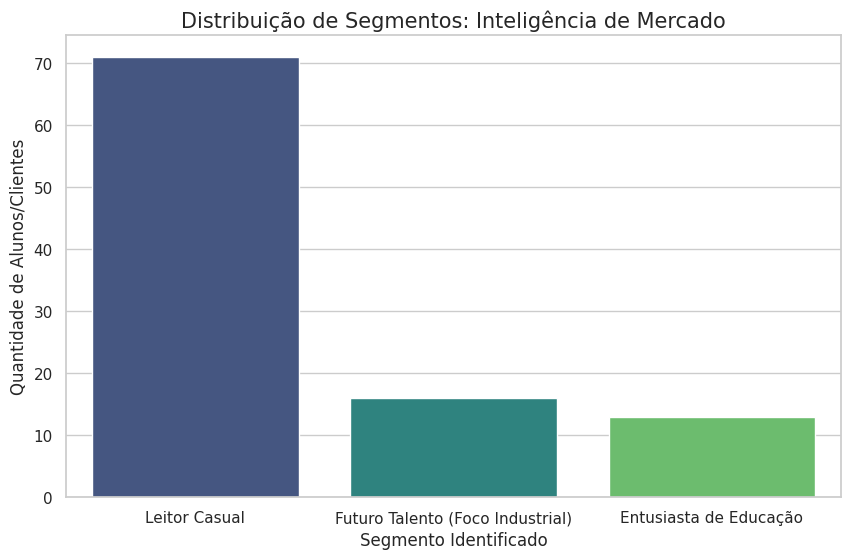

In [7]:
# Criando a lógica de Segmentação (Governança de Dados)
def classificar_segmento(row):
    if row['Valor_Compra'] > 160 and row['Visita_Industria'] == 1:
        return 'Futuro Talento (Foco Industrial)'
    elif row['Engajamento_Live'] > 7:
        return 'Entusiasta de Educação'
    else:
        return 'Leitor Casual'

# Aplicando a segmentação ao DataFrame principal
df['Segmento_Estrategico'] = df.apply(classificar_segmento, axis=1)

# Visualização da distribuição dos segmentos
plt.figure(figsize=(10, 6))
segmentos_count = df['Segmento_Estrategico'].value_counts()
sns.barplot(x=segmentos_count.index, y=segmentos_count.values, palette='viridis')

plt.title('Distribuição de Segmentos: Inteligência de Mercado', fontsize=15)
plt.xlabel('Segmento Identificado', fontsize=12)
plt.ylabel('Quantidade de Alunos/Clientes', fontsize=12)

# Exibindo os dados resumidos
print("Resumo da Segmentação de Clientes:")
display(segmentos_count.to_frame(name='Total de Clientes'))

plt.show()